In [24]:
import pandas as pd
import numpy as np

In [25]:
df = pd.read_csv("../datasets/housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [26]:
df.shape


(545, 13)

In [27]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns


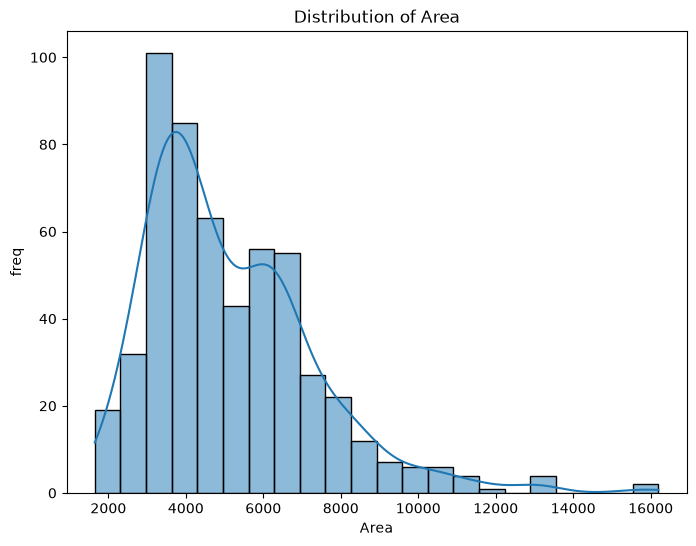

In [8]:
plt.figure(figsize=(8, 6))
sns.histplot(data = df , x="area", kde=True)
plt.title("Distribution of Area")
plt.xlabel("Area")
plt.ylabel("freq")
plt.show()

<Axes: xlabel='price'>

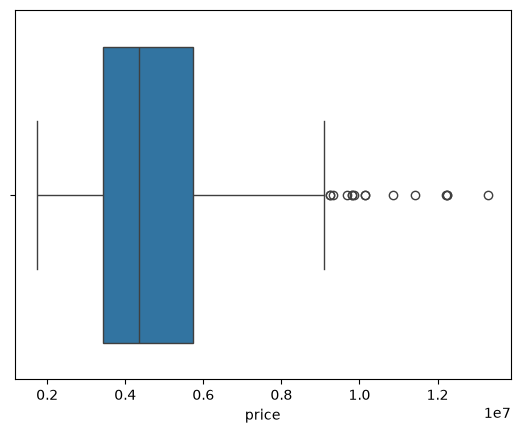

In [15]:
sns.boxplot(data = df , x = "price")

"Boxplots indicated the presence of outliers in features such as price and area. Since these observations likely represent genuine luxury properties rather than data entry errors, they were retained for modeling."

<Axes: xlabel='area', ylabel='price'>

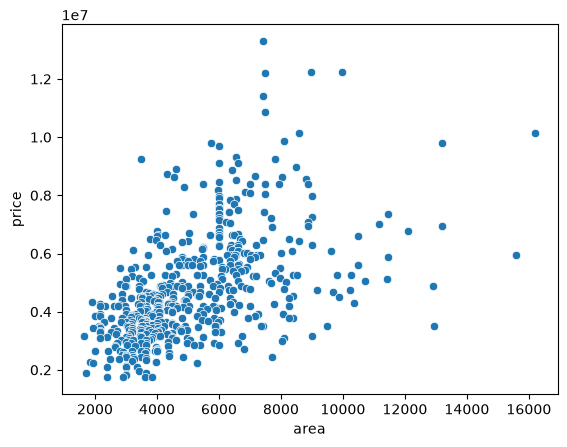

In [29]:
sns.scatterplot(data = df , x = "area" , y = "price")

# this shows area is influencing prices but there are also other features which influence price

<Axes: xlabel='prefarea', ylabel='price'>

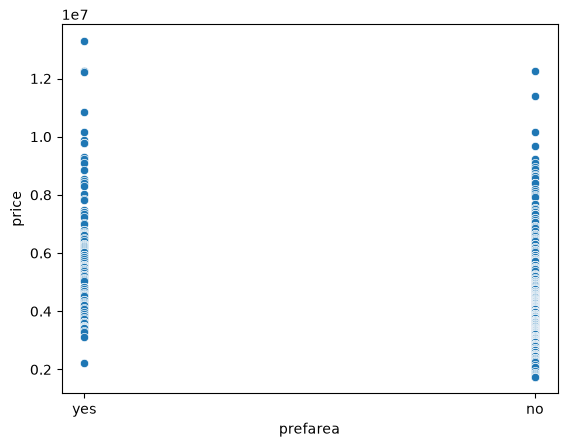

In [31]:
sns.scatterplot(data = df , x = "prefarea" , y = "price")

# DataPreprocessing

In [33]:
df.isnull().sum().sum()

np.int64(0)

In [35]:
df.duplicated().sum()

np.int64(0)

In [45]:
X = df.drop(columns = ["price"])
y = df["price"]
X = pd.get_dummies(X , drop_first = True, dtype = int)
X.dtypes



area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
parking                            int64
mainroad_yes                       int64
guestroom_yes                      int64
basement_yes                       int64
hotwaterheating_yes                int64
airconditioning_yes                int64
prefarea_yes                       int64
furnishingstatus_semi-furnished    int64
furnishingstatus_unfurnished       int64
dtype: object

In [48]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [51]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 519552.42, 57349.56, 521879.03,..., 266656.35, -62837.32,-192015.92]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.707e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](13,)","[32.97,26.68,25.52,...,15.65,13.29,12.5 ]"


In [52]:
y_pred = model.predict(X_test)
type(y_pred)

numpy.ndarray

In [67]:
from sklearn.metrics import(mean_absolute_error, mean_squared_error, r2_score)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2_s = r2_score(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2_s)

Mean Absolute Error (MAE): 970043.4039201643
Mean Squared Error (MSE): 1754318687330.668
Root Mean Squared Error (RMSE): 1324506.9600914402
R-squared (R2): 0.6529242642153176


In [58]:
result = pd.DataFrame({"Actual" : y_test, "Predicted" : y_pred})
result.head(10)

,Actual,Predicted
316,4060000,5.164654e+06
77,6650000,7.224722e+06
360,3710000,3.109863e+06
90,6440000,4.612075e+06
493,2800000,3.294646e+06
209,4900000,3.532275e+06
176,5250000,5.611775e+06
249,4543000,6.368146e+06
516,2450000,2.722857e+06
426,3353000,2.629406e+06


Text(0.5, 1.0, 'Actual vs Predicted Values')

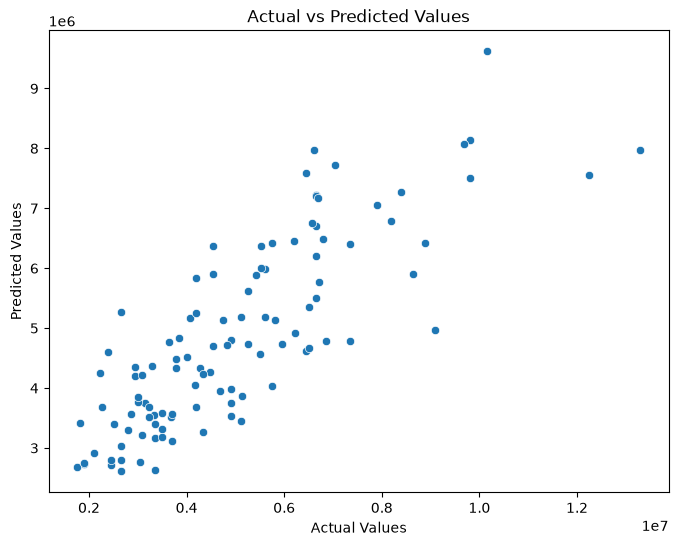

In [60]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data = result , x = "Actual" , y = "Predicted")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

Text(0.5, 1.0, 'Actual vs Predicted Values')

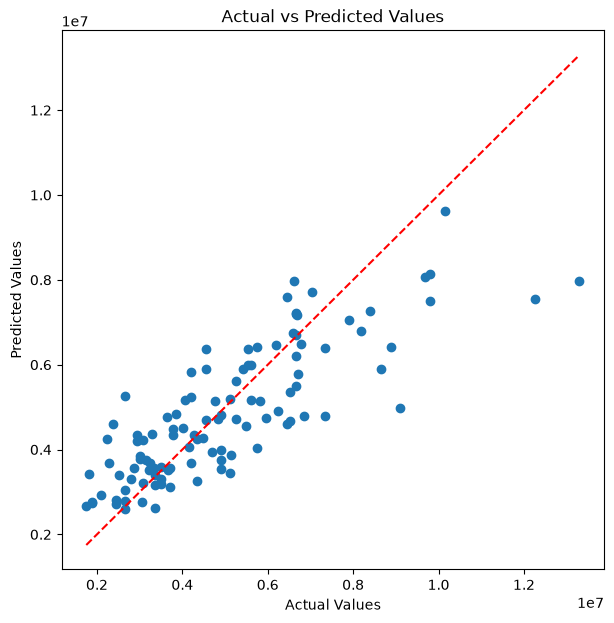

In [63]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],color='red', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

In [69]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2_score = r2_score(y_test, ridge_pred)
print("Ridge Regression Results:")
print("Mean Absolute Error (MAE):", ridge_mae)
print("Mean Squared Error (MSE):", ridge_mse)
print("Root Mean Squared Error (RMSE):", ridge_rmse)
print("R-squared (R2):", ridge_r2_score)


Ridge Regression Results:
Mean Absolute Error (MAE): 969857.9028478259
Mean Squared Error (MSE): 1754839327446.8064
Root Mean Squared Error (RMSE): 1324703.4866138182
R-squared (R2): 0.6528212603810126


In [73]:
print(model.coef_)
print(ridge.coef_)


[ 519552.41633999   57349.55941862  521879.02774805  349251.43890557
  192005.95366749  128498.62821472   88768.66768638  187067.80321388
  149862.70299085  365157.39385091  266656.3519933   -62837.32186493
 -192015.91798221]
[ 518507.03823036   58203.88705657  520891.30346237  348503.40960966
  192163.57004515  128787.60280692   89134.87763404  186543.41891169
  149497.5857089   364798.71516986  266213.76642621  -62469.29415218
 -191654.5723389 ]


In [75]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2_score = r2_score(y_test, lasso_pred)
print("Lasso Regression Results:")
print("Mean Absolute Error (MAE):", lasso_mae)
print("Mean Squared Error (MSE):", lasso_mse)
print("Root Mean Squared Error (RMSE):", lasso_rmse)
print("R-squared (R2):", lasso_r2_score)


Lasso Regression Results:
Mean Absolute Error (MAE): 970043.4045634499
Mean Squared Error (MSE): 1754318818534.6665
Root Mean Squared Error (RMSE): 1324507.0096208123
R-squared (R2): 0.6529242382578193


In [79]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso.coef_
})

coefficients


,Feature,Coefficient
0,area,519552.394333
1,bedrooms,57349.528830
2,bathrooms,521879.000655
3,stories,349251.391677
4,parking,192005.922676
5,mainroad_yes,128498.592284
6,guestroom_yes,88768.630737
7,basement_yes,187067.747077
8,hotwaterheating_yes,149862.601102
9,airconditioning_yes,365157.369117


In [81]:
from sklearn.preprocessing import PolynomialFeatures as polynomialFeature
poly = polynomialFeature(degree=2, include_bias=False)
poly_features = poly.fit_transform(X_train)
model_poly = LinearRegression()
model_poly.fit(poly_features, y_train)

poly_test_features = poly.transform(X_test)
poly_pred = model_poly.predict(poly_test_features)
poly_mae = mean_absolute_error(y_test, poly_pred)
poly_mse = mean_squared_error(y_test, poly_pred)
poly_rmse = np.sqrt(poly_mse)
poly_r2_score = r2_score(y_test, poly_pred)
print("Polynomial Regression Results:")
print("Mean Absolute Error (MAE):", poly_mae)
print("Mean Squared Error (MSE):", poly_mse)
print("Root Mean Squared Error (RMSE):", poly_rmse)
print("R-squared (R2):", poly_r2_score)


Polynomial Regression Results:
Mean Absolute Error (MAE): 1034749.2706758835
Mean Squared Error (MSE): 1901686413946.449
Root Mean Squared Error (RMSE): 1379016.466162188
R-squared (R2): 0.6237689217365154


| Model                 |     MAE |    RMSE |         R² |
| --------------------- | ------: | ------: | ---------: |
| Linear Regression     |  970043 | 1324507 | **0.6529** |
| Ridge Regression      |  969858 | 1324703 |     0.6528 |
| Lasso Regression      |  970043 | 1324507 |     0.6529 |
| Polynomial Regression | 1034749 | 1379016 |     0.6238 |
